In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision.transforms.v2 as v2

from src.dataset import NYUDepthDataset
from src.loss import SSIMLoss
from src.models import get_depth_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

csv_path = Path("../data/nyu2_train_subset.csv")

train_geom_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0)),
])

val_geom_transform = v2.Compose([
    v2.Resize((384, 384)),
])

train_img_transform = v2.Compose([
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_img_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

depth_transform = v2.Compose(
    [v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]
)

dataset = NYUDepthDataset(csv_path)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_dataset.dataset.geom_transform = train_geom_transform
train_dataset.dataset.img_transform = train_img_transform
train_dataset.dataset.depth_transform = depth_transform

val_dataset.dataset.geom_transform = val_geom_transform
val_dataset.dataset.img_transform = val_img_transform
val_dataset.dataset.depth_transform = depth_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = get_depth_model(pretrained=True).to(device)

depth_criterion = nn.SmoothL1Loss()
ssim_criterion = SSIMLoss().to(device)

ssim_weight = 0.05

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

n_epochs = 25

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
  optimizer, T_max=n_epochs, eta_min=1e-6
)

for param in model.parameters():
  param.requires_grad = True

for epoch in range(n_epochs):
  model.train()
  train_loss = 0.0
  for images, depths in train_loader:
    images, depths = images.to(device), depths.to(device)

    optimizer.zero_grad()
    preds = model(images)

    l_depth = depth_criterion(preds, depths)
    l_ssim = ssim_criterion(preds, depths)
    loss = l_depth + (ssim_weight * l_ssim)
    #print(f"l_depth: {l_depth}, l_ssim: {l_ssim}, loss: {loss}")

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  model.eval()
  val_loss = 0.0
  with torch.inference_mode():
    for images, depths in val_loader:
      images, depths = images.to(device), depths.to(device)
      preds = model(images)
      l_depth = depth_criterion(preds, depths)
      l_ssim = ssim_criterion(preds, depths)
      loss = l_depth + (ssim_weight * l_ssim)

      val_loss += loss.item()

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]


    print(
      f"Epoch [{epoch+1}/{n_epochs}] | LR: {current_lr:.6f} | "
      f"Train Loss: {train_loss/len(train_loader):.4f} | "
      f"Val Loss: {val_loss/len(val_loader):.4f}",
      flush=True,
  )

Using device: cuda
Epoch [1/25] | LR: 0.000100 | Train Loss: 0.0365 | Val Loss: 0.0425
Epoch [2/25] | LR: 0.000098 | Train Loss: 0.0134 | Val Loss: 0.0143
Epoch [3/25] | LR: 0.000097 | Train Loss: 0.0088 | Val Loss: 0.0126
Epoch [4/25] | LR: 0.000094 | Train Loss: 0.0070 | Val Loss: 0.0115
Epoch [5/25] | LR: 0.000091 | Train Loss: 0.0061 | Val Loss: 0.0109
Epoch [6/25] | LR: 0.000087 | Train Loss: 0.0055 | Val Loss: 0.0109
Epoch [7/25] | LR: 0.000082 | Train Loss: 0.0052 | Val Loss: 0.0107
Epoch [8/25] | LR: 0.000077 | Train Loss: 0.0049 | Val Loss: 0.0103
Epoch [9/25] | LR: 0.000072 | Train Loss: 0.0047 | Val Loss: 0.0105
Epoch [10/25] | LR: 0.000066 | Train Loss: 0.0047 | Val Loss: 0.0101
Epoch [11/25] | LR: 0.000060 | Train Loss: 0.0046 | Val Loss: 0.0104
Epoch [12/25] | LR: 0.000054 | Train Loss: 0.0047 | Val Loss: 0.0105
Epoch [13/25] | LR: 0.000047 | Train Loss: 0.0042 | Val Loss: 0.0102
Epoch [14/25] | LR: 0.000041 | Train Loss: 0.0042 | Val Loss: 0.0101
Epoch [15/25] | LR: 0.00

In [3]:
# sanity check
single_img, single_depth = next(iter(train_loader))
single_img, single_depth = single_img[:1].to(device), single_depth[:1].to(device)

for epoch in range(200):
  model.train()
  optimizer.zero_grad()
  preds = model(single_img)

  l_depth = depth_criterion(preds, single_depth)
  l_ssim = ssim_criterion(preds, single_depth)
  loss = l_depth + (ssim_weight * l_ssim)

  loss.backward()
  optimizer.step()

  if (epoch + 1) % 20 == 0 or epoch == 0:
    print(
        f"Epoch [{epoch+1}/200] | l_depth: {l_depth.item():.6f} | l_ssim:"
        f" {l_ssim.item():.6f} | loss: {loss.item():.6f}"
    )

Epoch [1/200] | l_depth: 0.018430 | l_ssim: 0.331449 | loss: 0.035003
Epoch [20/200] | l_depth: 0.000387 | l_ssim: 0.041928 | loss: 0.002483
Epoch [40/200] | l_depth: 0.000066 | l_ssim: 0.017731 | loss: 0.000953
Epoch [60/200] | l_depth: 0.000019 | l_ssim: 0.011074 | loss: 0.000573
Epoch [80/200] | l_depth: 0.000013 | l_ssim: 0.008582 | loss: 0.000442
Epoch [100/200] | l_depth: 0.000012 | l_ssim: 0.007314 | loss: 0.000378
Epoch [120/200] | l_depth: 0.000008 | l_ssim: 0.006234 | loss: 0.000320
Epoch [140/200] | l_depth: 0.000008 | l_ssim: 0.005733 | loss: 0.000295
Epoch [160/200] | l_depth: 0.000007 | l_ssim: 0.005078 | loss: 0.000261
Epoch [180/200] | l_depth: 0.000006 | l_ssim: 0.004718 | loss: 0.000242
Epoch [200/200] | l_depth: 0.000006 | l_ssim: 0.004493 | loss: 0.000231


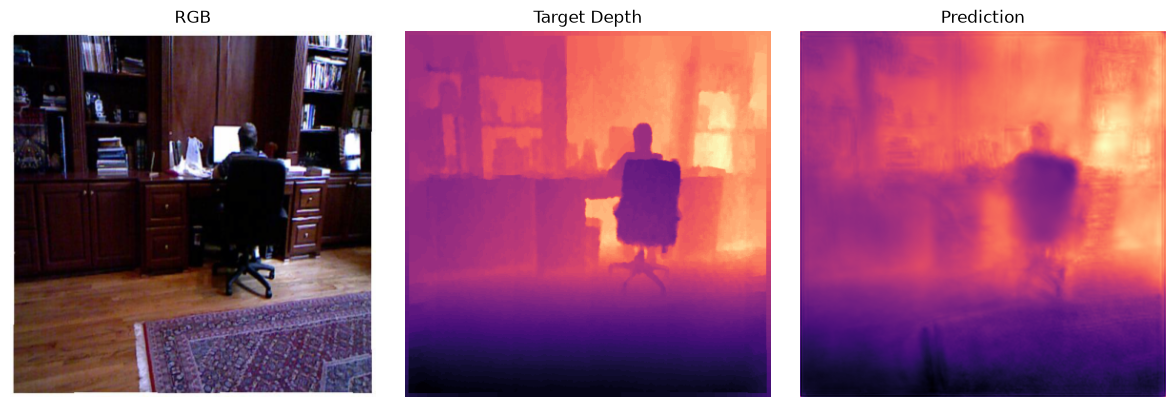

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
model.eval()

img_tensor, depth_gt = dataset[41]

with torch.inference_mode():
    pred = model(img_tensor.unsqueeze(0).to(device)).squeeze().cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
rgb = img_tensor.permute(1, 2, 0).numpy() * std + mean
rgb = np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rgb)
axes[0].set_title("RGB")
axes[1].imshow(depth_gt.squeeze().numpy(), cmap="magma")
axes[1].set_title("Target Depth")
axes[2].imshow(pred, cmap="magma")
axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig("result.png")
plt.show()

In [ ]:
import gc
import torch

if 'model' in globals():
    del model

gc.collect()
torch.cuda.empty_cache()
